### Анализ данных пациентов страховой фирмы
Необходимо изучить данные о пациентах

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams['figure.figsize'] = [22, 17]

In [4]:
# Загружаем датасет и смотрим его структуру
df_insurance = pd.read_csv('data/insurance.csv')
df_insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df_insurance.shape

(1338, 7)

In [6]:
df_insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
df_insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


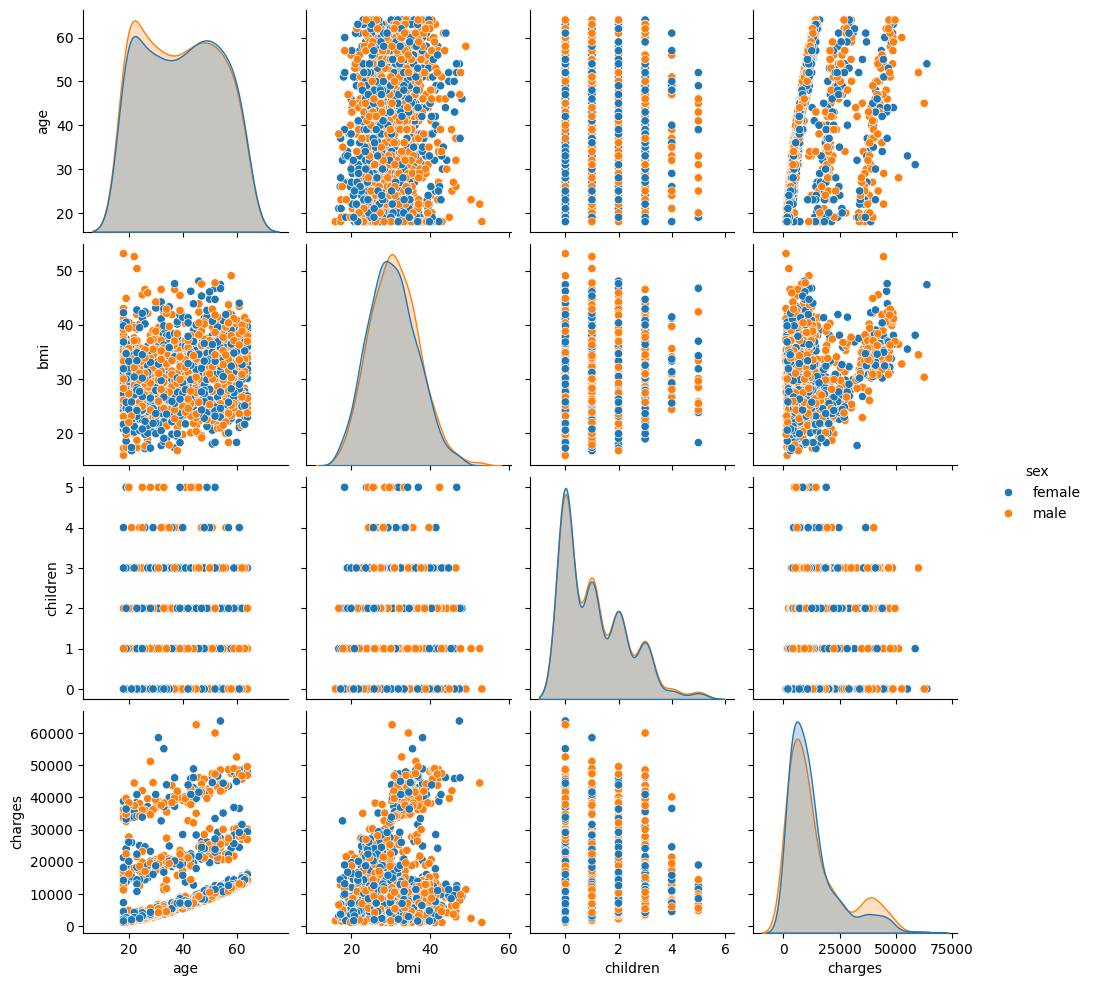

In [8]:
sns.pairplot(df_insurance, hue="sex")

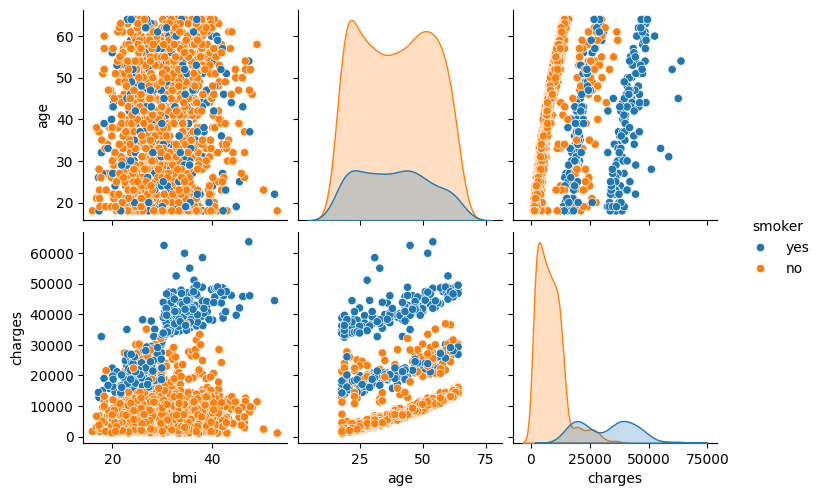

In [ ]:
# Выведем 6 графиков
sns.pairplot(
    df_insurance,
    x_vars=["bmi",  "age", "charges"],        
    y_vars=["age", "charges"], hue="smoker")  

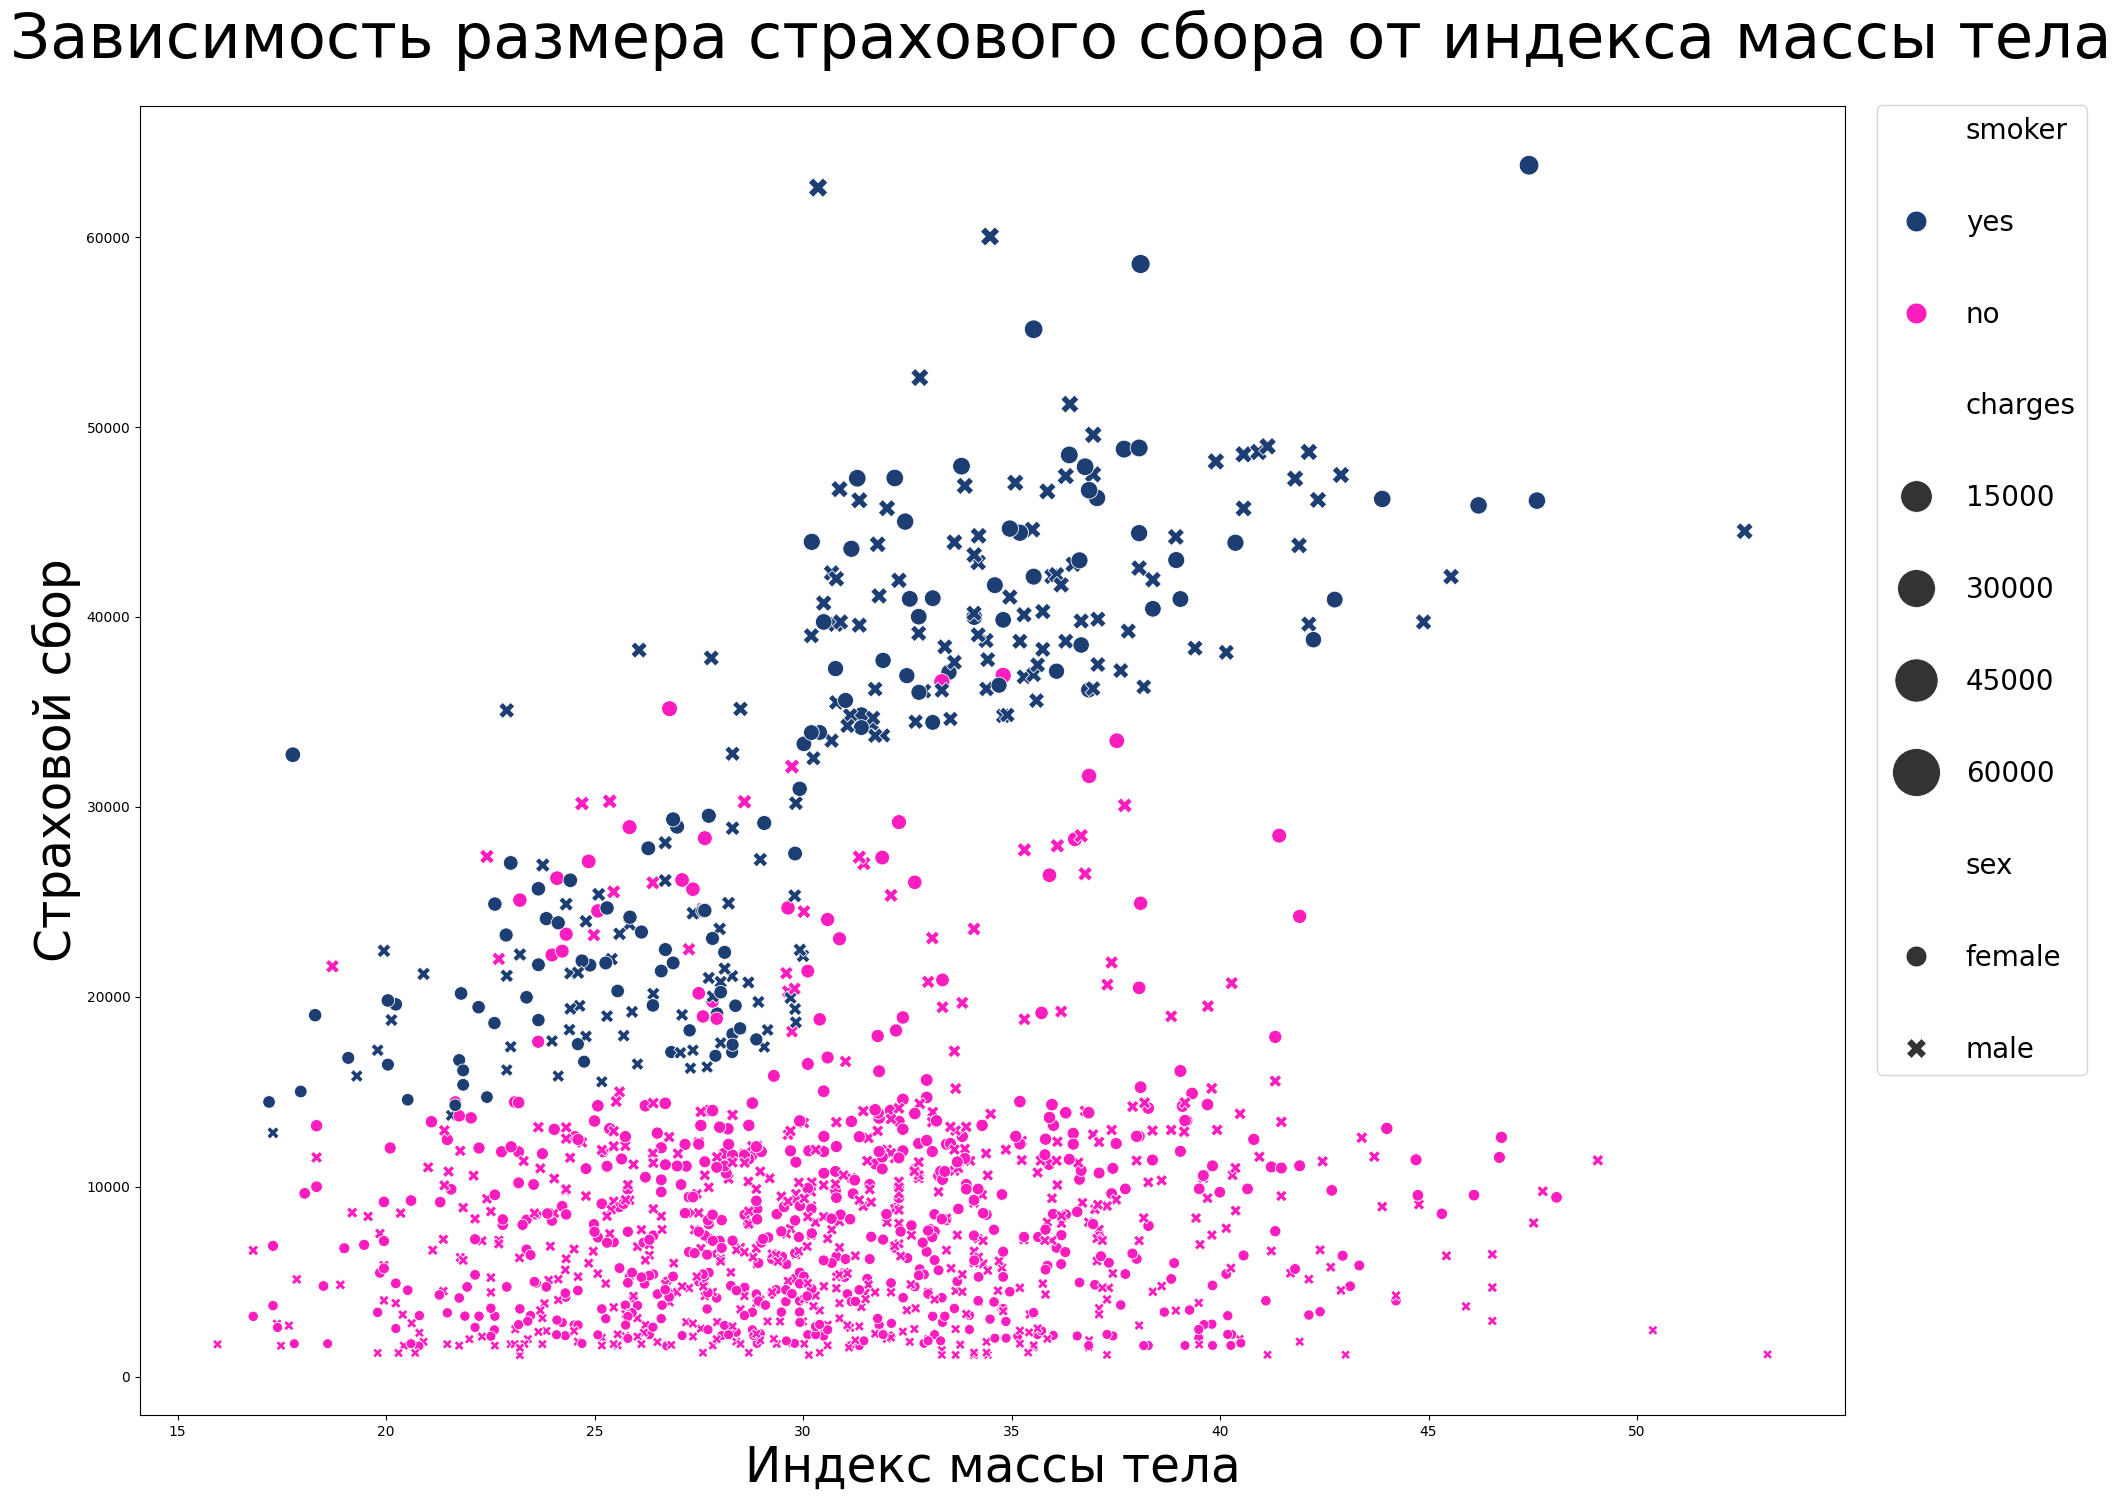

In [ ]:
sns.scatterplot(data=df_insurance,
    x="bmi", y="charges", hue="smoker", size = "charges", sizes=(50, 200), style="sex",
               palette=['#1D3E72','#FC1DBE'])
plt.xlabel("Индекс массы тела", size = 35)
plt.ylabel("Страховой сбор", size = 35)
plt.title("Зависимость размера страхового сбора от индекса массы тела",
          size = 45, y = 1.03, x = 0.54)
plt.legend(fontsize = '7', loc="right", bbox_to_anchor=(1.15, 0.63),
           prop={'size': 20}, markerscale=2.5, labelspacing = 2.3)


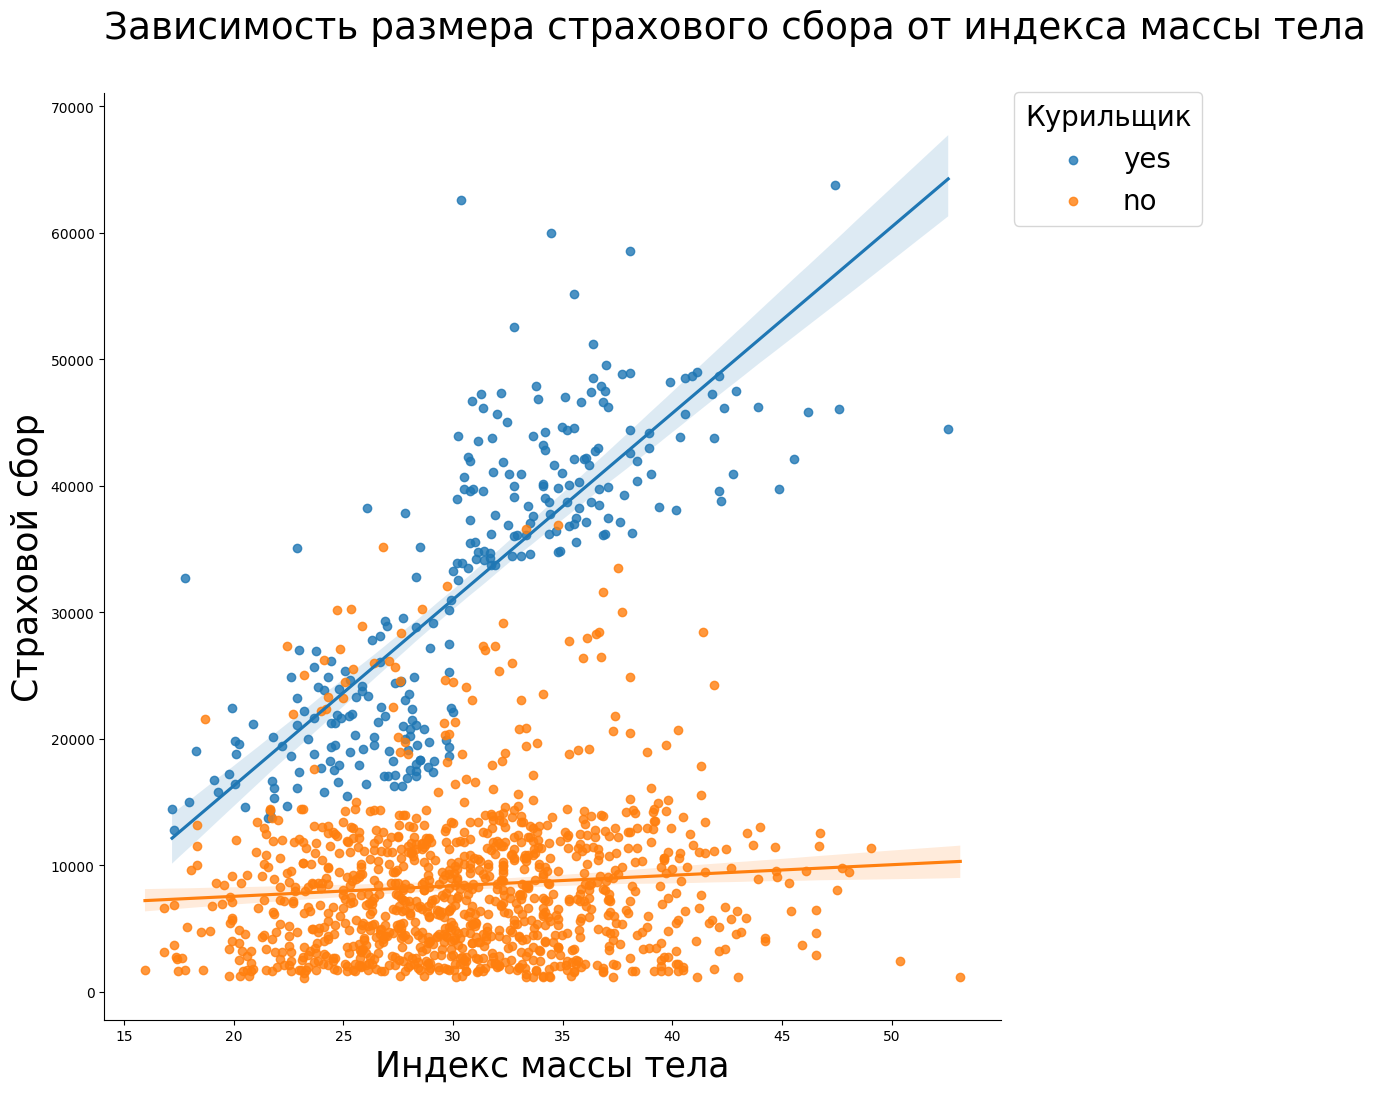

In [11]:
# Добавляем линию регрессии и доверительный интервал, настраиваем отображение

sns.lmplot(
    data=df_insurance,
    x="bmi", y="charges", hue="smoker", height=10, legend = False)

plt.xlabel("Индекс массы тела", size = 25)
plt.ylabel("Страховой сбор", size = 25)
plt.title("Зависимость размера страхового сбора от индекса массы тела", size = 27, y = 1.05, loc = 'left')

plt.legend(fontsize = '17', loc="right", bbox_to_anchor=(1.24, 0.929), prop={'size': 20},
           title = "Курильщик", title_fontsize = '20')


plt.show()

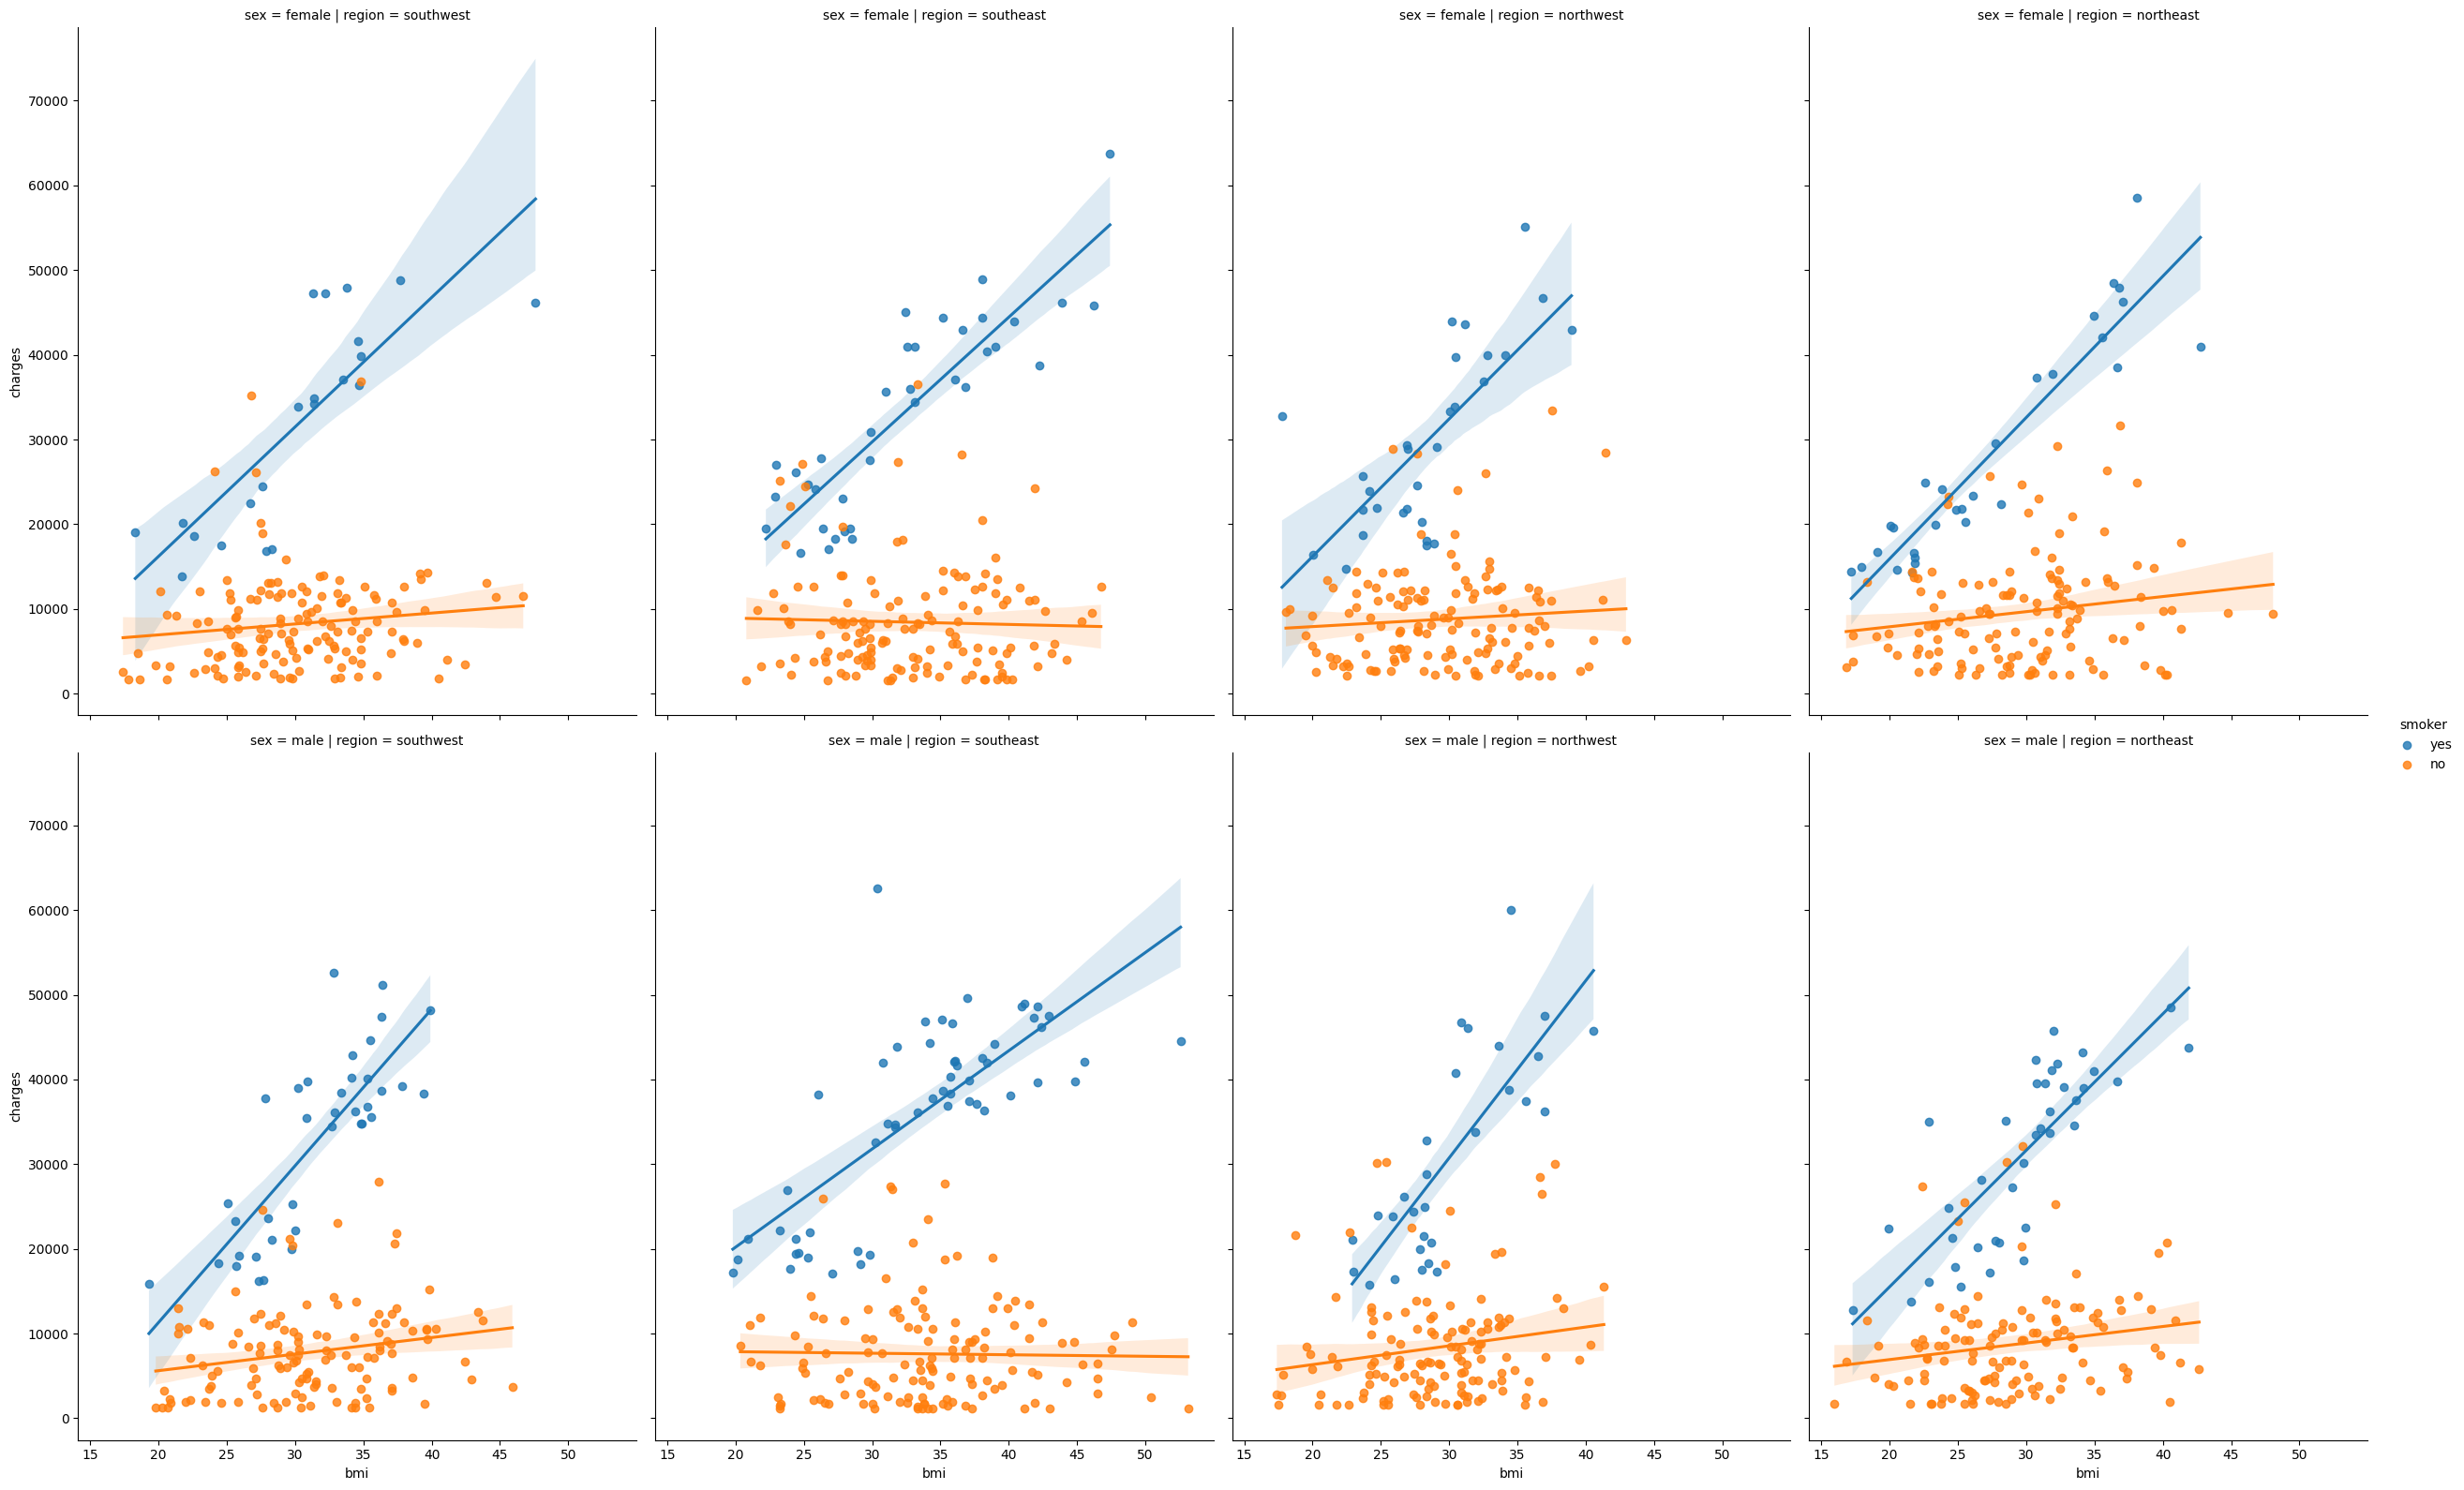

In [12]:
# Выводим несколько графиков
# Верхний ряд — графики для женщин, нижний — для мужчин. Каждая колонка — отдельный регион

sns.lmplot(
    data=df_insurance,
    x="bmi", y="charges", hue="smoker", height=8, col ='region', row = "sex", aspect=.8)

plt.savefig('Ваш график.png') # Сохраняем графики в формате .png
plt.show()